In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving youtube.csv to youtube.csv


In [4]:
df = pd.read_csv("youtube.csv")

In [5]:
print("Preview of Data:")
display(df.head())

Preview of Data:


,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,publish_country,views,likes,dislikes,comment_count
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,13-11-2017,17:00 to 17:59,US,748374,57527,2966,15954
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,13-11-2017,7:00 to 7:59,US,2418783,97185,6146,12703
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,12-11-2017,19:00 to 19:59,US,3191434,146033,5339,8181
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,13-11-2017,11:00 to 11:59,US,343168,10172,666,2146
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,12-11-2017,18:00 to 18:59,US,2095731,132235,1989,17518


In [6]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_date', 'time_frame', 'publish_country', 'views', 'likes', 'dislikes', 'comment_count']


In [7]:
# Convert dates
df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')
df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')

# Remove missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Filter low-quality rows
df = df[(df['views'] > 1000) & (df['likes'] > 0)]

/tmp/ipykernel_16349/950896524.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')
/tmp/ipykernel_16349/950896524.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')


In [8]:
# Rename columns (optional for clarity)
df.rename(columns={
    'publish_country': 'country'
}, inplace=True)

# Final check
print("Cleaned Data Shape:", df.shape)
df.head()

Cleaned Data Shape: (59949, 12)


,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,country,views,likes,dislikes,comment_count
3400,6ZfuNTqbHE8,2012-01-17,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,24,2017-11-29,13:00 to 13:59,US,56367282,2157727,34077,303178
3402,XbuQAbG2AZ0,2012-01-17,"Jay-Z and Dean Baquet, in Conversation",The New York Times,25,2017-11-30,14:00 to 14:59,US,224270,7006,331,1127
3403,evhLzq7Gsak,2012-01-17,Matt Lauer Has Been Fired From NBC News | TODAY,TODAY,25,2017-11-29,14:00 to 14:59,US,1717225,10041,4266,9335
3404,KXHrCBkIxQQ,2012-01-17,ALL THE MONEY IN THE WORLD - Official Trailer ...,Sony Pictures Entertainment,24,2017-11-29,20:00 to 20:59,US,616077,5816,934,1116
3405,8z_cg5CypRc,2012-01-17,Kelly Clarkson Carpool Karaoke,The Late Late Show with James Corden,24,2017-11-30,6:00 to 6:59,US,3074263,96530,1011,7415


In [9]:
from textblob import TextBlob

# Function for sentiment
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity


In [10]:
# Apply
df['sentiment_score'] = df['title'].apply(get_sentiment)

In [11]:
# Convert to labels
def label_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['sentiment_score'].apply(label_sentiment)

df[['title', 'sentiment']].head()

,title,sentiment
3400,Marvel Studios' Avengers: Infinity War Officia...,Neutral
3402,"Jay-Z and Dean Baquet, in Conversation",Neutral
3403,Matt Lauer Has Been Fired From NBC News | TODAY,Neutral
3404,ALL THE MONEY IN THE WORLD - Official Trailer ...,Neutral
3405,Kelly Clarkson Carpool Karaoke,Neutral


In [12]:
import sqlite3

# Create DB
conn = sqlite3.connect(':memory:')
df.to_sql('youtube', conn, index=False, if_exists='replace')

# Query: Avg views per category
query = """
SELECT category_id, AVG(views) AS avg_views
FROM youtube
GROUP BY category_id
ORDER BY avg_views DESC
"""

result = pd.read_sql(query, conn)
result

,category_id,avg_views
0,10,8.451944e+06
1,1,2.246521e+06
2,24,1.765568e+06
3,30,1.621202e+06
4,29,1.556885e+06
5,28,1.372894e+06
6,17,1.171955e+06
7,23,1.089096e+06
8,20,9.619501e+05
9,2,9.010978e+05


In [13]:
# Count how many days each video trended
trending_days = df.groupby('video_id')['trending_date'].nunique().reset_index()
trending_days.columns = ['video_id', 'days_trending']

trending_days.head()

,video_id,days_trending
0,#NAME?,77
1,--2K8l6BWfw,1
2,--45ws7CEN0,1
3,--728h8mnDY,2
4,-01MUE3GK7U,1


Category Popularity

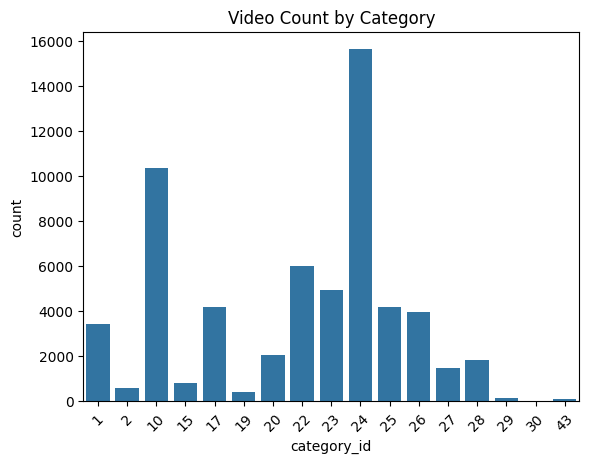

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.countplot(x='category_id', data=df)
plt.title("Video Count by Category")
plt.xticks(rotation=45)
plt.show()

Views vs Sentiment

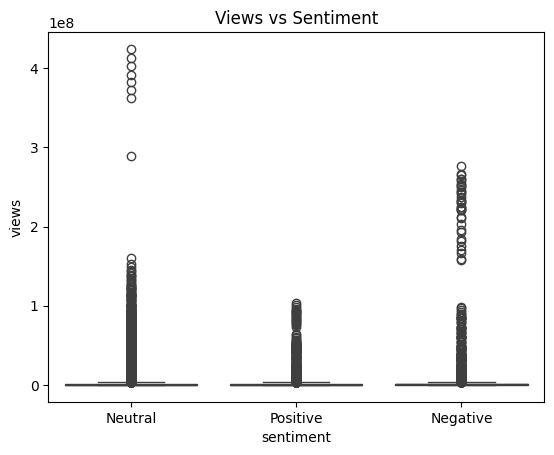

In [15]:
plt.figure()
sns.boxplot(x='sentiment', y='views', data=df)
plt.title("Views vs Sentiment")
plt.show()

Region-wise Comparison

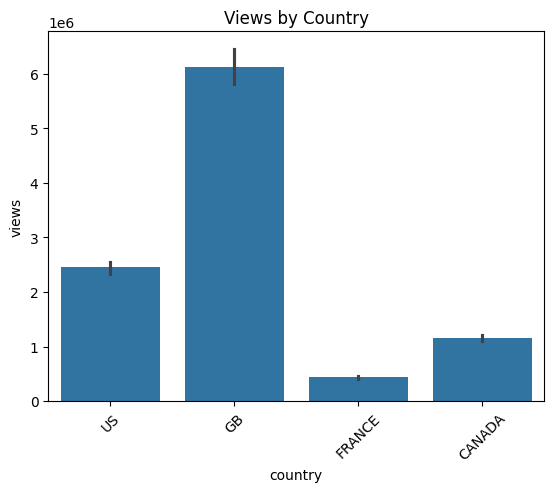

In [16]:
plt.figure()
sns.barplot(x='country', y='views', data=df)
plt.title("Views by Country")
plt.xticks(rotation=45)
plt.show()

Trending Duration Distribution

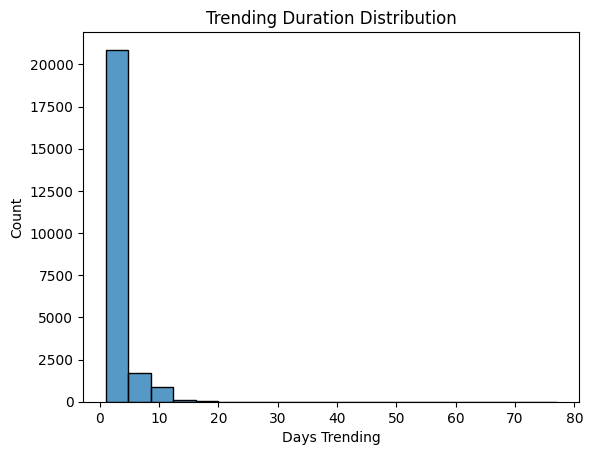

In [17]:
plt.figure()
sns.histplot(trending_days['days_trending'], bins=20)
plt.title("Trending Duration Distribution")
plt.xlabel("Days Trending")
plt.show()

Time-Series Trend

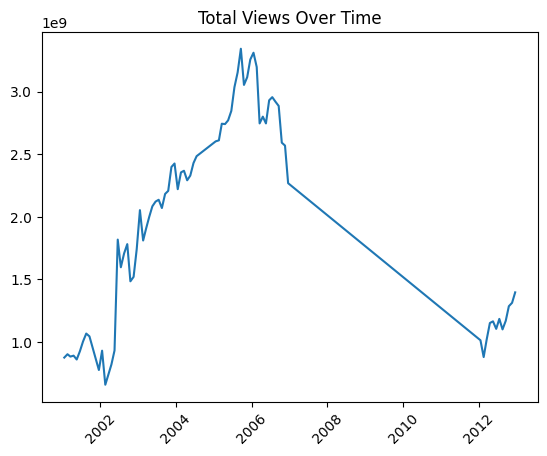

In [18]:
# Views over time
daily_views = df.groupby('trending_date')['views'].sum().reset_index()

plt.figure()
plt.plot(daily_views['trending_date'], daily_views['views'])
plt.title("Total Views Over Time")
plt.xticks(rotation=45)
plt.show()

In [19]:
df.to_csv("cleaned_youtube_data.csv", index=False)